**SECTION 1 — IMPORT LIBRARIES**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


**SECTION 1 — IMPORT LIBRARIES**

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
path_aapl = "/content/drive/MyDrive/CSV File/AI and Finance dataset/aapl_us_2025.csv"
path_msft = "/content/drive/MyDrive/CSV File/AI and Finance dataset/MSFT_yfinance.csv"

aapl = pd.read_csv(path_aapl)


msft = pd.read_csv(path_msft)

msft.columns = msft.columns.str.strip()

if '' in msft.columns:
    msft = msft.drop(columns=[''])

In [24]:
# Load CSV files
aapl = pd.read_csv(path_aapl)
msft = pd.read_csv(path_msft)

# Clean columns
msft.columns = msft.columns.str.strip()

# Convert Date
aapl["Date"] = pd.to_datetime(aapl["Date"])
msft["Date"] = pd.to_datetime(msft["Date"])

# Keep required columns
aapl = aapl[["Date", "Close"]].rename(columns={"Close":"Close_AAPL"})
msft = msft[["Date", "Close"]].rename(columns={"Close":"Close_MSFT"})

# Merge
data = pd.merge(aapl, msft, on="Date", how="inner")
data = data.sort_values("Date").reset_index(drop=True)

# Compute returns
data["R_AAPL"] = data["Close_AAPL"].pct_change()
data["R_MSFT"] = data["Close_MSFT"].pct_change()

data = data.dropna().reset_index(drop=True)

data.head()

,Date,Close_AAPL,Close_MSFT,R_AAPL,R_MSFT
0,2010-01-05,6.46558,23.137524,0.001715,0.000323
1,2010-01-06,6.36237,22.995537,-0.015963,-0.006137
2,2010-01-07,6.35113,22.756380,-0.001767,-0.010400
3,2010-01-08,6.39387,22.913322,0.006730,0.006897
4,2010-01-11,6.33709,22.621864,-0.008880,-0.012720


**SECTION 3 — TRAIN / TEST SPLIT**

In [25]:
data["Year"] = data["Date"].dt.year

train = data[data["Year"] < 2024].copy()
test  = data[data["Year"] >= 2024].copy()

print("Train size:", train.shape)
print("Test size:", test.shape)


Train size: (3521, 6)
Test size: (263, 6)


**SECTION 4 — MARKOWITZ OPTIMIZATION (TRAINING SET)**

In [26]:
mu_train = train[["R_AAPL","R_MSFT"]].mean().values
cov_train = train[["R_AAPL","R_MSFT"]].cov().values

inv_cov = np.linalg.inv(cov_train)
ones = np.ones(len(mu_train))

# Minimum Variance Portfolio
w_min = inv_cov @ ones / (ones.T @ inv_cov @ ones)

# Tangency Portfolio (rf = 0)
w_tan = inv_cov @ mu_train / (ones.T @ inv_cov @ mu_train)

print("Minimum Variance Weights:", np.round(w_min,4))
print("Tangency Portfolio Weights:", np.round(w_tan,4))


Minimum Variance Weights: [0.398 0.602]
Tangency Portfolio Weights: [0.5909 0.4091]


**SECTION 5 — MARKOWITZ BULLET (TRAIN + TEST)**

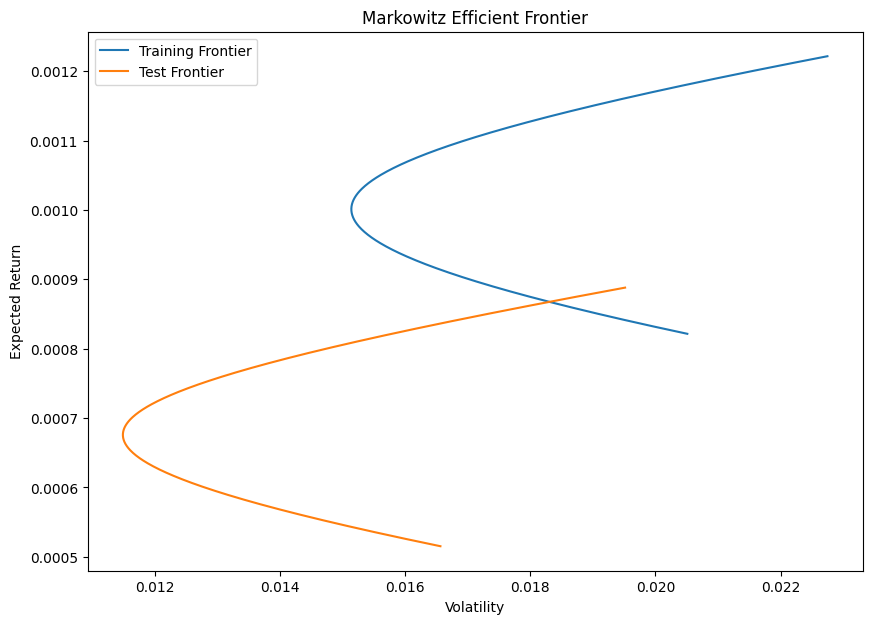

In [27]:
def plot_frontier(mu, cov, title):

    weights = np.linspace(-0.5, 1.5, 500)
    returns = []
    vol = []

    for w in weights:
        w_vec = np.array([w, 1-w])
        returns.append(np.dot(w_vec, mu))
        vol.append(np.sqrt(w_vec.T @ cov @ w_vec))

    plt.plot(vol, returns, label=title)

# Plot both
plt.figure(figsize=(10,7))

plot_frontier(mu_train, cov_train, "Training Frontier")
plot_frontier(test[["R_AAPL","R_MSFT"]].mean().values,
              test[["R_AAPL","R_MSFT"]].cov().values,
              "Test Frontier")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Markowitz Efficient Frontier")
plt.legend()
plt.show()


**SECTION 6 — DYNAMIC PORTFOLIO SIMULATION (TEST SET)**

In [28]:
initial_capital = 100000

portfolio_value = initial_capital
holding_AAPL = w_min[0] * portfolio_value
holding_MSFT = w_min[1] * portfolio_value

V_p, V_1, V_2 = [], [], []
trade_AAPL, trade_MSFT = [], []

for i in range(len(test)):

    r1 = test.iloc[i]["R_AAPL"]
    r2 = test.iloc[i]["R_MSFT"]

    holding_AAPL *= (1 + r1)
    holding_MSFT *= (1 + r2)

    portfolio_value = holding_AAPL + holding_MSFT

    target_AAPL = w_min[0] * portfolio_value
    target_MSFT = w_min[1] * portfolio_value

    trade_AAPL.append(target_AAPL - holding_AAPL)
    trade_MSFT.append(target_MSFT - holding_MSFT)

    holding_AAPL = target_AAPL
    holding_MSFT = target_MSFT

    V_p.append(portfolio_value)
    V_1.append(holding_AAPL)
    V_2.append(holding_MSFT)

test = test.reset_index(drop=True)
test["V_P"] = V_p
test["V_AAPL"] = V_1
test["V_MSFT"] = V_2
test["Trade_AAPL"] = trade_AAPL
test["Trade_MSFT"] = trade_MSFT

test.head()


,Date,Close_AAPL,Close_MSFT,R_AAPL,R_MSFT,Year,V_P,V_AAPL,V_MSFT,Trade_AAPL,Trade_MSFT
0,2024-01-02,184.938,365.421570,-0.035792,-0.013749,2024,97747.856495,38901.504553,58846.351942,528.136708,-528.136708
1,2024-01-03,183.554,365.155579,-0.007484,-0.000728,2024,97413.899223,38768.596878,58645.302345,158.215200,-158.215200
2,2024-01-04,181.222,362.534668,-0.012705,-0.007178,2024,96500.427816,38405.055279,58095.372538,129.002109,-129.002109
3,2024-01-05,180.495,362.347473,-0.004012,-0.000516,2024,96316.362461,38331.801301,57984.561160,80.813825,-80.813825
4,2024-01-08,184.859,369.185486,0.024178,0.018871,2024,98337.398253,39136.129252,59201.269001,-122.456619,122.456619


**EXPLICIT DAILY CAPITAL ALLOCATION TABLE (TEST SET)**

In [29]:


capital_table = test[[
    "Date",
    "V_P",
    "V_AAPL",
    "V_MSFT"
]].copy()

print("Daily Capital Allocation (Test Set 2024–2025)")
display(capital_table.head())


Daily Capital Allocation (Test Set 2024–2025)


,Date,V_P,V_AAPL,V_MSFT
0,2024-01-02,97747.856495,38901.504553,58846.351942
1,2024-01-03,97413.899223,38768.596878,58645.302345
2,2024-01-04,96500.427816,38405.055279,58095.372538
3,2024-01-05,96316.362461,38331.801301,57984.561160
4,2024-01-08,98337.398253,39136.129252,59201.269001


**DAILY TRADE QUANTITIES (BUY / SELL)**

In [30]:


trade_table = test[[
    "Date",
    "Trade_AAPL",
    "Trade_MSFT"
]].copy()

print("Daily Trade Quantities (Positive = Buy, Negative = Sell)")
display(trade_table.head())


Daily Trade Quantities (Positive = Buy, Negative = Sell)


,Date,Trade_AAPL,Trade_MSFT
0,2024-01-02,528.136708,-528.136708
1,2024-01-03,158.215200,-158.215200
2,2024-01-04,129.002109,-129.002109
3,2024-01-05,80.813825,-80.813825
4,2024-01-08,-122.456619,122.456619


**SECTION 7 — PORTFOLIO RETURNS**

In [31]:
test["Portfolio_Return"] = (
    w_min[0] * test["R_AAPL"] +
    w_min[1] * test["R_MSFT"]
)


**SECTION 8 — ROLLING VaR (DYNAMIC, 250-DAY WINDOW)**

In [32]:
window = 250

rolling_VaR = test["Portfolio_Return"].rolling(window).quantile(0.05)
test["Rolling_VaR"] = rolling_VaR


**SECTION 9 — BACKTESTING & 2025 STRESS EVALUATION**

In [33]:


test["Breach"] = test["Portfolio_Return"] < test["Rolling_VaR"]

# Full test violation rate
violation_total = test["Breach"].mean()

# 2025 only
test_2025 = test[test["Date"].dt.year == 2025]
violation_2025 = test_2025["Breach"].mean()

expected_rate = 0.05

stress_summary = pd.DataFrame({
    "Metric": [
        "Full Test Violation Rate (2024–2025)",
        "Stress Year Violation Rate (2025)",
        "Expected Theoretical Rate (95% VaR)"
    ],
    "Value": [
        violation_total,
        violation_2025,
        expected_rate
    ]
})

print("Stress Period Backtesting Summary")
display(stress_summary)

# Optional: Compare deviation
print("Deviation from Expected (2025):",
      round(violation_2025 - expected_rate,4))


Stress Period Backtesting Summary


,Metric,Value
0,Full Test Violation Rate (2024–2025),0.003802
1,Stress Year Violation Rate (2025),0.090909
2,Expected Theoretical Rate (95% VaR),0.050000


Deviation from Expected (2025): 0.0409


**KUPIEC TEST**

In [34]:


from scipy.stats import chi2
import numpy as np

# Number of observations
T = len(test)

# Number of violations
N = test["Breach"].sum()

# Expected probability
p = 0.05

# Observed probability
p_hat = N / T

# Likelihood Ratio (Kupiec)
LR_pof = -2 * (
    np.log(((1 - p)**(T - N) * p**N)) -
    np.log(((1 - p_hat)**(T - N) * p_hat**N))
)

# Critical value (chi-square with 1 df at 5%)
critical_value = chi2.ppf(0.95, df=1)

# p-value
p_value = 1 - chi2.cdf(LR_pof, df=1)

print("Kupiec Proportion of Failures Test")
print("-----------------------------------")
print("Total Observations (T):", T)
print("Number of Violations (N):", N)
print("Observed Violation Rate:", round(p_hat,4))
print("Expected Violation Rate:", p)
print("LR Statistic:", round(LR_pof,4))
print("Critical Value (5% level):", round(critical_value,4))
print("p-value:", round(p_value,4))

if LR_pof > critical_value:
    print("Result: Reject H0 → VaR model is NOT accurate.")
else:
    print("Result: Fail to Reject H0 → VaR model is statistically accurate.")


Kupiec Proportion of Failures Test
-----------------------------------
Total Observations (T): 263
Number of Violations (N): 1
Observed Violation Rate: 0.0038
Expected Violation Rate: 0.05
LR Statistic: 19.7286
Critical Value (5% level): 3.8415
p-value: 0.0
Result: Reject H0 → VaR model is NOT accurate.


**SECTION 10 — PERFORMANCE METRICS**

In [35]:
mean_return = test["Portfolio_Return"].mean()
std_return = test["Portfolio_Return"].std()
sharpe = mean_return / std_return * np.sqrt(252)

cumulative_return = (1 + test["Portfolio_Return"]).cumprod()
drawdown = cumulative_return / cumulative_return.cummax() - 1
max_drawdown = drawdown.min()

print("Sharpe Ratio:", round(sharpe,3))
print("Maximum Drawdown:", round(max_drawdown,3))


Sharpe Ratio: 0.942
Maximum Drawdown: -0.132


**SECTION 11 — VISUALIZATION**

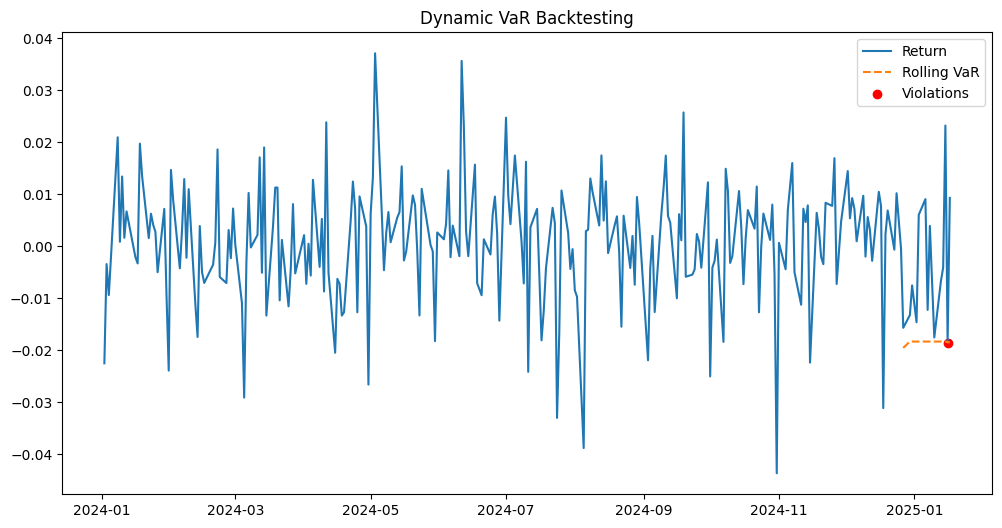

In [36]:
plt.figure(figsize=(12,6))
plt.plot(test["Date"], test["Portfolio_Return"], label="Return")
plt.plot(test["Date"], test["Rolling_VaR"], label="Rolling VaR", linestyle="--")
plt.scatter(test["Date"][test["Breach"]],
            test["Portfolio_Return"][test["Breach"]],
            color="red", label="Violations")

plt.legend()
plt.title("Dynamic VaR Backtesting")
plt.show()


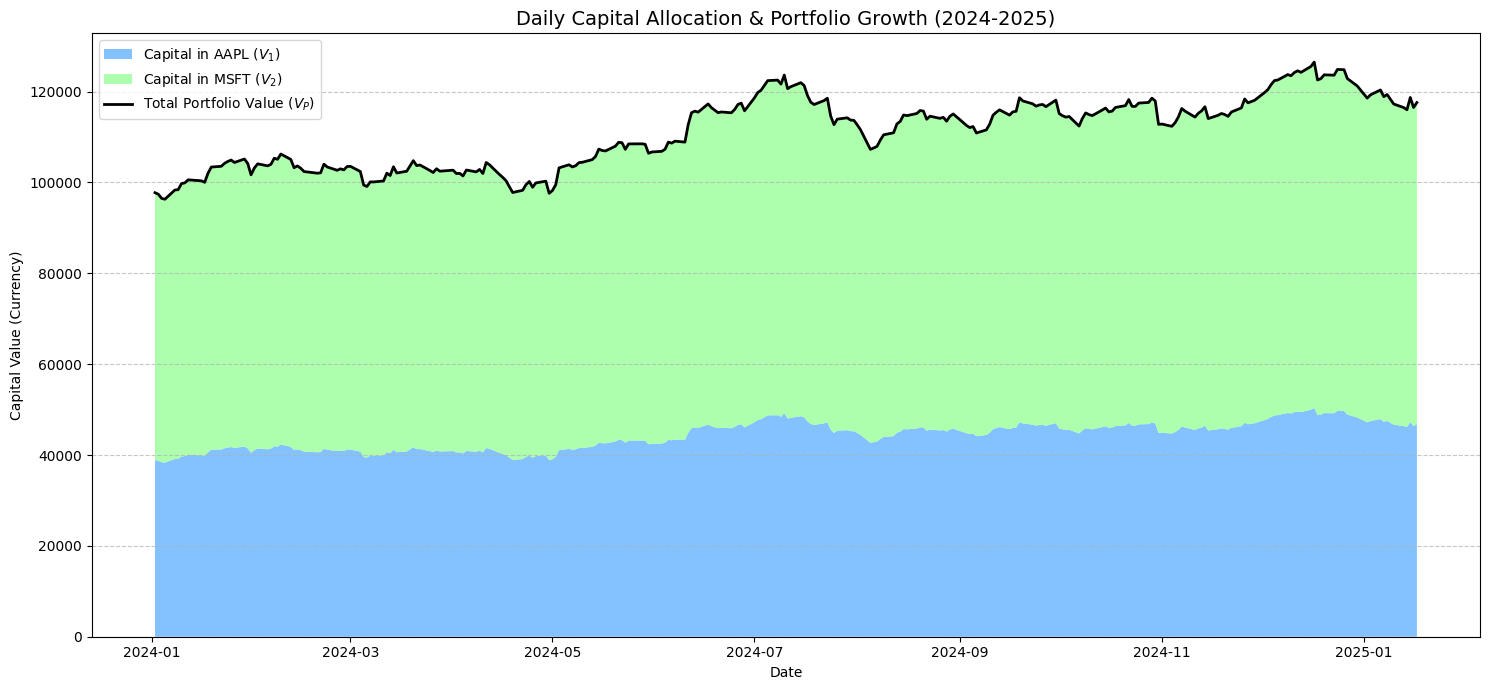

Final Portfolio Value: 117,598.01


In [37]:
import matplotlib.pyplot as plt

# Create the visualization for Capital Allocation (Step 2.iii)
plt.figure(figsize=(15, 7))

# Plotting the stacked area for V_AAPL and V_MSFT using capital_table
plt.stackplot(capital_table["Date"],
              capital_table['V_AAPL'], capital_table['V_MSFT'],
              labels=['Capital in AAPL ($V_1$)', 'Capital in MSFT ($V_2$)'],
              colors=['#66b3ff', '#99ff99'], alpha=0.8)

# Adding the Total Portfolio Value line (V_P)
plt.plot(capital_table["Date"], capital_table['V_P'], color='black', linewidth=2, label='Total Portfolio Value ($V_P$)')

plt.title('Daily Capital Allocation & Portfolio Growth (2024-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Capital Value (Currency)')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print a summary of the final state
final_v = capital_table['V_P'].iloc[-1]
print(f"Final Portfolio Value: {final_v:,.2f}")